In [2]:
# Cell 1: Imports
import os
from pathlib import Path
import math

%matplotlib widget

import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

from scipy.spatial.distance import cdist 
from scipy import linalg
from scipy.ndimage import map_coordinates

print("numpy:", np.__version__)
print("PIL:", Image.__version__)
print("cv2:", cv2.__version__)
print("SciPy loaded successfully.")

numpy: 2.2.6
PIL: 10.2.0
cv2: 4.12.0
SciPy loaded successfully.


In [3]:
# Cell 2: Simplified Path Setup
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"

# Only create paths we actually need
DATA_RAW = DATA_DIR / "raw" / "OriginalImages"
DATA_LANDMARKS = DATA_DIR / "landmarks"
DATA_ALIGNED = DATA_DIR / "aligned"

# Create only essential directories
DATA_LANDMARKS.mkdir(parents=True, exist_ok=True)
DATA_ALIGNED.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_RAW:", DATA_RAW)
print("DATA_LANDMARKS:", DATA_LANDMARKS)
print("DATA_ALIGNED:", DATA_ALIGNED)
print("\n✓ Path setup complete")

PROJECT_ROOT: D:\Projects 2025\Caricature Generation
DATA_RAW: D:\Projects 2025\Caricature Generation\data\raw\OriginalImages
DATA_LANDMARKS: D:\Projects 2025\Caricature Generation\data\landmarks
DATA_ALIGNED: D:\Projects 2025\Caricature Generation\data\aligned

✓ Path setup complete


In [4]:
# Cell 3: Essential helper functions only
def load_landmarks(p):
    """Load landmarks from .npy file."""
    p = Path(p)
    if not p.exists():
        return None
    try:
        arr = np.load(str(p))
        if arr.ndim == 2 and arr.shape[1] == 2:
            return arr.astype(np.float32)
    except Exception as e:
        print(f"Error loading {p.name}: {e}")
    return None

def collect_photo_files(root_dir, limit=None):
    """Collect image files starting with 'p'."""
    files = []
    for img_path in root_dir.rglob('*'):
        if img_path.suffix.lower() not in {'.jpg', '.jpeg', '.png', '.bmp'}:
            continue
        if not img_path.stem.lower().startswith('p'):
            continue
        files.append(img_path)
        if limit and len(files) >= limit:
            break
    return files

def bbox_diag(pts):
    """Calculate bounding box diagonal."""
    xs, ys = pts[:, 0], pts[:, 1]
    return np.linalg.norm([xs.max() - xs.min(), ys.max() - ys.min()])

def normalize_shape(pts):
    """Center and scale landmarks to unit size."""
    centroid = pts.mean(axis=0)
    scale = bbox_diag(pts)
    if scale < 1e-6:
        scale = 1.0
    return (pts - centroid) / scale

print("✓ Helper functions defined")

✓ Helper functions defined


In [5]:
# Cell 4: Landmark extraction
import face_alignment
from face_alignment import LandmarksType

DEMO_LIMIT = 100
DEVICE = 'cuda' if __import__('torch').cuda.is_available() else 'cpu'

fa = face_alignment.FaceAlignment(LandmarksType.TWO_D, device=DEVICE, flip_input=False)

def get_largest_face(landmarks_list):
    """Return index of largest face."""
    areas = []
    for pts in landmarks_list:
        w = pts[:, 0].max() - pts[:, 0].min()
        h = pts[:, 1].max() - pts[:, 1].min()
        areas.append(w * h)
    return int(np.argmax(areas))

# Process images
all_files = collect_photo_files(DATA_RAW, DEMO_LIMIT)
print(f"Found {len(all_files)} images to process")

count_ok = 0
count_fail = 0

for img_path in tqdm(all_files, desc="Extracting landmarks"):
    rel_path = img_path.relative_to(DATA_RAW)
    out_path = DATA_LANDMARKS / rel_path.with_suffix('.npy')
    
    # Skip if already processed
    if out_path.exists():
        continue
    
    try:
        img = np.array(Image.open(img_path).convert('RGB'))
        preds = fa.get_landmarks(img)
        
        if preds is None or len(preds) == 0:
            count_fail += 1
            continue
        
        # Get largest face
        face_idx = get_largest_face(preds)
        pts = preds[face_idx].astype(np.float32)
        
        # Save landmarks only
        out_path.parent.mkdir(parents=True, exist_ok=True)
        np.save(str(out_path), pts)
        count_ok += 1
        
    except Exception as e:
        count_fail += 1
        continue

print(f"\n{'='*60}")
print(f"✓ Success: {count_ok}")
print(f"✗ Failed: {count_fail}")
print(f"{'='*60}")

Found 100 images to process


Extracting landmarks: 100%|████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 1540.08it/s]


✓ Success: 0
✗ Failed: 0


Scanning D:\Projects 2025\Caricature Generation\data\landmarks for landmarks...
Found 100 files. Using 100 shapes with 68 points.
✓ Saved to: D:\Projects 2025\Caricature Generation\data\aligned\mean_shape.npy


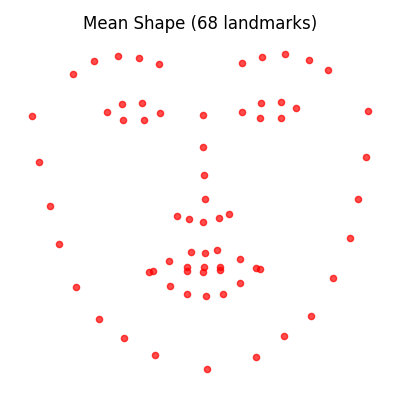

In [6]:
# Cell 5: Build mean normalized shape - single file output
MIN_LANDMARKS = 5
MEAN_SHAPE_PATH = DATA_ALIGNED / "mean_shape.npy"
DATA_ALIGNED.mkdir(parents=True, exist_ok=True)

def build_mean_shape(landmark_root=DATA_LANDMARKS):
    """Build mean normalized shape from landmarks."""
    all_norms = []
    counts = {}
    
    print(f"Scanning {landmark_root} for landmarks...")
    
    for lm_path in landmark_root.rglob("*.npy"):
        if not lm_path.stem.lower().startswith('p'):
            continue
        
        try:
            pts = np.load(str(lm_path))
            if pts.ndim != 2 or pts.shape[1] != 2 or pts.shape[0] < MIN_LANDMARKS:
                continue
            
            all_norms.append(normalize_shape(pts))
            counts[pts.shape[0]] = counts.get(pts.shape[0], 0) + 1
        except:
            continue
    
    if len(all_norms) == 0:
        raise RuntimeError("No valid landmarks found!")
    
    # Use most common landmark count
    common_n = max(counts, key=counts.get)
    final_norms = [n for n in all_norms if n.shape[0] == common_n]
    
    print(f"Found {len(all_norms)} files. Using {len(final_norms)} shapes with {common_n} points.")
    
    # Compute mean
    mean_norm = np.mean(np.stack(final_norms, axis=0), axis=0)
    np.save(MEAN_SHAPE_PATH, mean_norm)
    print(f"✓ Saved to: {MEAN_SHAPE_PATH}")
    
    return mean_norm

mean_norm = build_mean_shape()

# Visualize
plt.figure(figsize=(4, 4))
plt.scatter(mean_norm[:, 0], -mean_norm[:, 1], s=20, c='red', alpha=0.7)
plt.axis('equal')
plt.axis('off')
plt.title(f"Mean Shape ({len(mean_norm)} landmarks)")
plt.tight_layout()
plt.show()

In [7]:
# Cell 6: Create canonical target and transform utilities
OUTPUT_SIZE = (256, 256)
TARGET_FACE_SCALE = 0.45
TARGET_PTS_PATH = DATA_ALIGNED / "target_pts.npy"

# Load or use existing mean
if MEAN_SHAPE_PATH.exists():
    mean_norm = np.load(str(MEAN_SHAPE_PATH))
else:
    raise RuntimeError("Mean shape not found. Run Cell 5 first.")

# Create target points
w_out, h_out = OUTPUT_SIZE
center_out = np.array([w_out/2.0, h_out/2.0], dtype=np.float32)
target_scale = min(w_out, h_out) * TARGET_FACE_SCALE
target_pts = (mean_norm * target_scale + center_out).astype(np.float32)
np.save(str(TARGET_PTS_PATH), target_pts)
print(f"✓ Saved target_pts: {TARGET_PTS_PATH}")

def estimate_transform(src_pts, dst_pts, method='affine'):
    """Estimate transform with fallback strategies."""
    src = np.asarray(src_pts, dtype=np.float32)
    dst = np.asarray(dst_pts, dtype=np.float32)
    
    # Try RANSAC
    try:
        if method == 'affine':
            M, _ = cv2.estimateAffine2D(src, dst, method=cv2.RANSAC, 
                                        ransacReprojThreshold=5.0, maxIters=2000)
        else:
            M, _ = cv2.estimateAffinePartial2D(src, dst, method=cv2.RANSAC,
                                               ransacReprojThreshold=5.0, maxIters=2000)
        if M is not None:
            return M
    except:
        pass
    
    # Try LMEDS
    try:
        if method == 'affine':
            M, _ = cv2.estimateAffine2D(src, dst, method=cv2.LMEDS)
        else:
            M, _ = cv2.estimateAffinePartial2D(src, dst, method=cv2.LMEDS)
        if M is not None:
            return M
    except:
        pass
    
    # Fallback: simple similarity
    src_center = src.mean(axis=0)
    dst_center = dst.mean(axis=0)
    src_scale = np.sqrt(((src - src_center) ** 2).sum() / len(src))
    dst_scale = np.sqrt(((dst - dst_center) ** 2).sum() / len(dst))
    scale = dst_scale / (src_scale + 1e-8)
    
    M = np.array([
        [scale, 0, dst_center[0] - scale * src_center[0]],
        [0, scale, dst_center[1] - scale * src_center[1]]
    ], dtype=np.float32)
    
    return M

def transform_landmarks(pts, M):
    """Apply 2x3 affine matrix to landmarks."""
    pts = np.asarray(pts, dtype=np.float32)
    ones = np.ones((pts.shape[0], 1), dtype=np.float32)
    homog = np.concatenate([pts, ones], axis=1)
    return homog @ M.T

print("✓ Transform functions ready")

✓ Saved target_pts: D:\Projects 2025\Caricature Generation\data\aligned\target_pts.npy
✓ Transform functions ready


In [8]:
# Cell 7: Align images with hair preservation
ALIGNMENT_METHOD = 'affine'
CROP_STRATEGY = 'adaptive'
FACE_SCALE = 0.45
BG_FILL = (30, 30, 30)

def get_face_bbox_with_hair(pts, strategy='adaptive'):
    """Calculate bbox including hair region."""
    x_min, y_min = pts.min(axis=0)
    x_max, y_max = pts.max(axis=0)
    
    width = x_max - x_min
    height = y_max - y_min
    
    # Estimate hair region using anatomical proportions
    if len(pts) >= 27:
        eyebrow_top = pts[17:27, 1].min()
        jaw_bottom = pts[8, 1] if len(pts) > 8 else y_max
        face_height = jaw_bottom - eyebrow_top
        head_top_estimate = eyebrow_top - (face_height * 0.75)
    else:
        head_top_estimate = y_min - (height * 0.5)
    
    # Strategy-based padding
    if strategy == 'tight':
        pad_top = max(0, y_min - head_top_estimate) + height * 0.1
        pad_bottom = height * 0.1
        pad_x = width * 0.15
    elif strategy == 'adaptive':
        pad_top = max(0, y_min - head_top_estimate) + height * 0.25
        pad_bottom = height * 0.15
        pad_x = width * 0.25
    else:  # loose
        pad_top = max(0, y_min - head_top_estimate) + height * 0.45
        pad_bottom = height * 0.2
        pad_x = width * 0.35
    
    return [x_min - pad_x, y_min - pad_top, x_max + pad_x, y_max + pad_bottom]

def crop_and_align(img, pts, output_size, face_scale=0.45, crop_strategy='adaptive'):
    """Crop face with hair and align."""
    h_img, w_img = img.shape[:2]
    w_out, h_out = output_size
    
    # Get bbox
    bbox = get_face_bbox_with_hair(pts, strategy=crop_strategy)
    x_min, y_min, x_max, y_max = bbox
    
    # Clamp to image bounds
    x_min = max(0, int(x_min))
    y_min = max(0, int(y_min))
    x_max = min(w_img, int(x_max))
    y_max = min(h_img, int(y_max))
    
    # Crop
    cropped_img = img[y_min:y_max, x_min:x_max]
    cropped_pts = pts - np.array([x_min, y_min])
    
    # Calculate transform
    crop_center = np.array([cropped_img.shape[1] / 2, cropped_img.shape[0] / 2])
    target_center = np.array([w_out / 2, h_out / 2])
    
    face_w = cropped_pts[:, 0].max() - cropped_pts[:, 0].min()
    face_h = cropped_pts[:, 1].max() - cropped_pts[:, 1].min()
    target_scale = (min(w_out, h_out) * face_scale) / max(face_w, face_h)
    
    pts_centered = cropped_pts - crop_center
    target_pts_temp = pts_centered * target_scale + target_center
    
    M = estimate_transform(cropped_pts, target_pts_temp, method=ALIGNMENT_METHOD)
    
    # Warp
    warped = cv2.warpAffine(cropped_img, M, (w_out, h_out),
                            flags=cv2.INTER_LINEAR,
                            borderMode=cv2.BORDER_CONSTANT,
                            borderValue=BG_FILL)
    
    transformed_pts = transform_landmarks(cropped_pts, M)
    
    return warped, M, transformed_pts

# Process all images
raw_images = collect_photo_files(DATA_RAW, DEMO_LIMIT)
print(f"Found {len(raw_images)} images to align")

count_ok = 0
count_skipped = 0

for img_path in tqdm(raw_images, desc="Aligning with hair"):
    rel_path = img_path.relative_to(DATA_RAW)
    stem = rel_path.stem
    
    lm_src = DATA_LANDMARKS / rel_path.with_suffix('.npy')
    out_img = DATA_ALIGNED / f"{stem}_aligned.png"
    out_lm = DATA_ALIGNED / f"{stem}_aligned.npy"
    out_M = DATA_ALIGNED / f"{stem}_affine.npy"
    
    if not lm_src.exists():
        continue
    
    if out_img.exists() and out_lm.exists() and out_M.exists():
        count_skipped += 1
        continue
    
    try:
        src_pts = np.load(str(lm_src)).astype(np.float32)
        img = np.array(Image.open(img_path).convert('RGB'))
        
        warped, M, transformed_pts = crop_and_align(
            img, src_pts, OUTPUT_SIZE,
            face_scale=FACE_SCALE,
            crop_strategy=CROP_STRATEGY
        )
        
        out_img.parent.mkdir(parents=True, exist_ok=True)
        Image.fromarray(warped).save(str(out_img))
        np.save(str(out_lm), transformed_pts.astype(np.float32))
        np.save(str(out_M), M.astype(np.float32))
        
        count_ok += 1
    except Exception as e:
        continue

print(f"\n{'='*60}")
print(f"✓ Aligned: {count_ok}")
print(f"○ Skipped: {count_skipped}")
print(f"Output: {DATA_ALIGNED}")
print(f"{'='*60}")

Found 100 images to align


Aligning with hair: 100%|████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 65.84it/s]


✓ Aligned: 36
○ Skipped: 64
Output: D:\Projects 2025\Caricature Generation\data\aligned
